In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import calendar
import datetime as dt


In [11]:
from google.colab import files
uploaded =files.upload()


Saving Unemployment in India.csv to Unemployment in India (1).csv


In [2]:
from google.colab import files
uploaded =files.upload()

Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020.csv


In [12]:
# loading the dataset
df1 = pd.read_csv('Unemployment in India.csv')
df2 = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

In [13]:
# Clean column names (strip trailing/leading spaces)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

In [14]:
# Drop rows with missing values (common in the first dataset)
df1 = df1.dropna()

In [15]:
# Standardize Date format
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

In [17]:
# Add Month and Year features for Trend Analysis
df1['Month'] = df1['Date'].dt.month_name()
df1['Year'] = df1['Date'].dt.year
df2['Month'] = df2['Date'].dt.month_name()
df2['Year'] = df2['Date'].dt.year

In [ ]:
# INVESTIGATING THE IMPACT OF COVID-19
# Defining Pre-COVID (before March 2020) and Post-Lockdown periods
pre_covid = df1[df1['Date'] < '2020-03-01']
post_covid = df1[df1['Date'] >= '2020-03-01']
avg_pre = pre_covid['Estimated Unemployment Rate (%)'].mean()
avg_post = post_covid['Estimated Unemployment Rate (%)'].mean()
print(f"Average Unemployment Rate Pre-COVID: {avg_pre:.2f}%")
print(f"Average Unemployment Rate During/Post COVID: {avg_post:.2f}%")

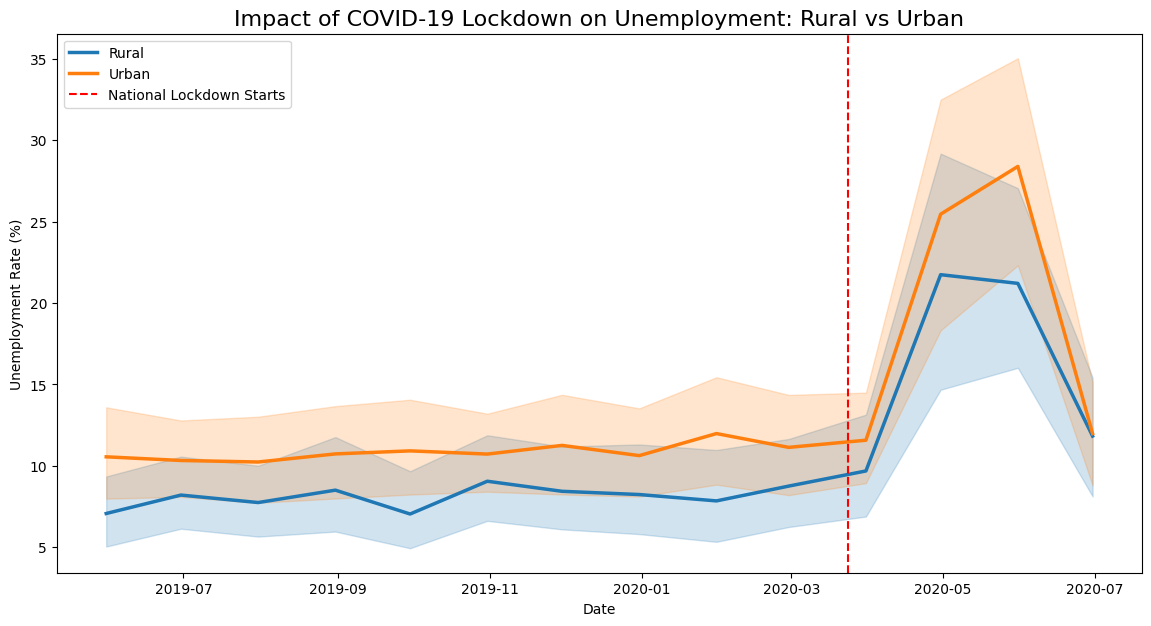

In [20]:
# Visualization: The Sudden Economic Shock
plt.figure(figsize=(14, 7))
sns.lineplot(data=df1, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', linewidth=2.5)
plt.axvline(pd.to_datetime('2020-03-24'), color='red', linestyle='--', label='National Lockdown Starts')
plt.title('Impact of COVID-19 Lockdown on Unemployment: Rural vs Urban', fontsize=16)
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.show()

/tmp/ipykernel_716/3211887006.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




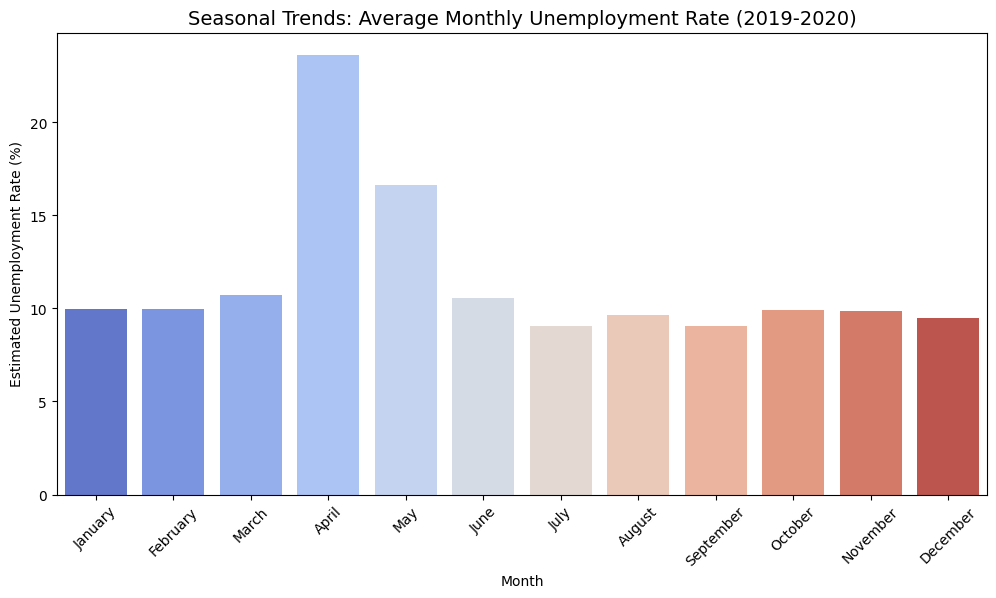

In [21]:
# SEASONAL TREND ANALYSIS
# ---------------------------------------------------------
# Analyze average monthly rate to find seasonal patterns
# We re-index to ensure months are in chronological order
months_order = list(calendar.month_name)[1:]
monthly_seasonality = df1.groupby('Month')['Estimated Unemployment Rate (%)'].mean().reindex(months_order).dropna().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Month', y='Estimated Unemployment Rate (%)', data=monthly_seasonality, palette='coolwarm')
plt.title('Seasonal Trends: Average Monthly Unemployment Rate (2019-2020)', fontsize=14)
plt.xticks(rotation=45)
plt.show()

In [22]:
# 4. REGIONAL VULNERABILITY (Interactive Visualization)
# Analyzing the peak lockdown month (April 2020) across states
lockdown_peak = df2[df2['Date'] == '2020-04-30'].sort_values(by='Estimated Unemployment Rate (%)', ascending=False)

fig = px.bar(lockdown_peak, x='Region', y='Estimated Unemployment Rate (%)',
             color='Estimated Unemployment Rate (%)',
             title='State-wise Peak Unemployment During Lockdown (April 2020)',
             labels={'Estimated Unemployment Rate (%)': 'Unemployment %'},
             template='plotly_dark')
fig.show()

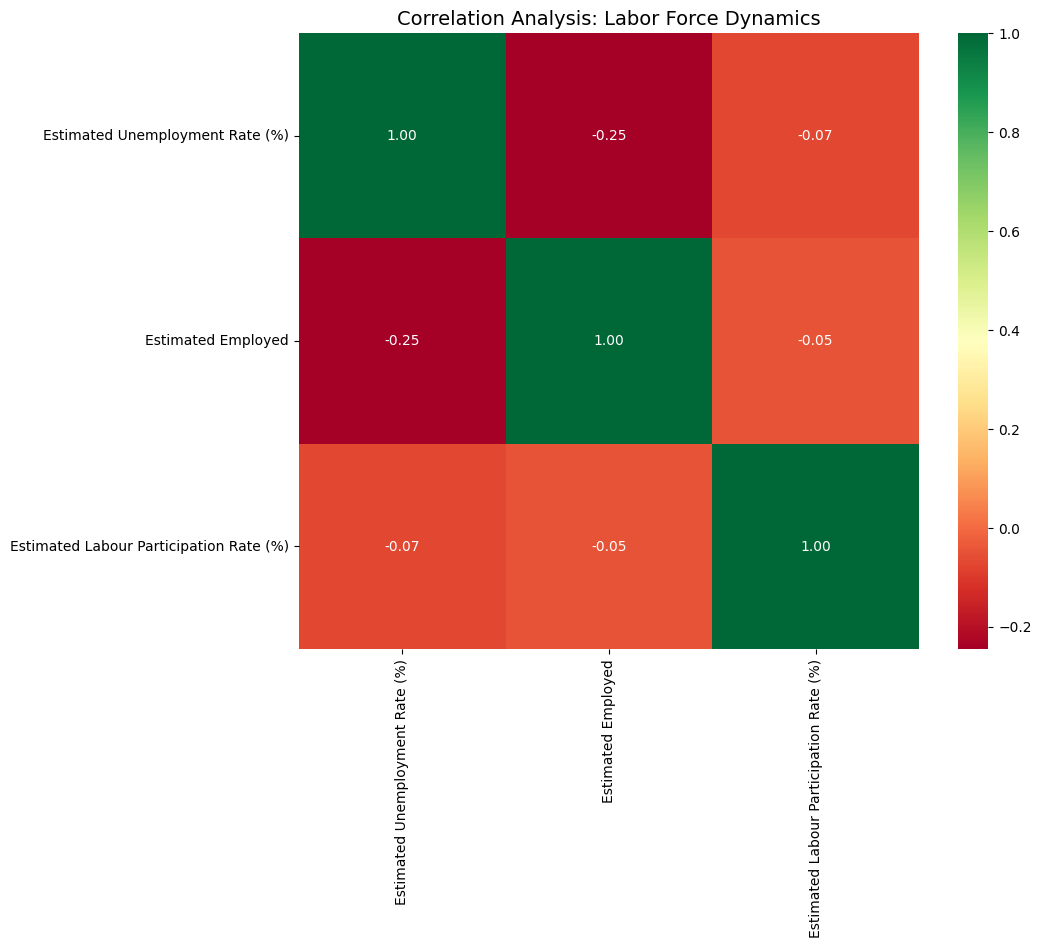

In [23]:
#CORRELATION & LABOR DYNAMICS
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
# Checking relationship between Unemployment, Employment, and Participation
correlation = df2[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr()
sns.heatmap(correlation, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Analysis: Labor Force Dynamics', fontsize=14)
plt.show()

In [ ]:
#EXECUTIVE INSIGHTS FOR POLICY MAKERS
# ---------------------------------------------------------
print("\n" + "="*60)
print("             EXECUTIVE SUMMARY & POLICY INSIGHTS")
print("="*60)
print("1. THE LOCKDOWN EFFECT: The unemployment rate spiked by nearly 90% in April 2020,")
print("   highlighting extreme vulnerability in the informal sector.")
print("2. URBAN VULNERABILITY: Urban areas consistently showed higher unemployment ")
print("   volatility than rural areas during mobility restrictions.")
print("3. SEASONALITY: There is a notable rise in May/June, likely due to pre-monsoon ")
print("   agricultural cycles and the influx of fresh graduates into the market.")
print("4. STATE TARGETING: States like Haryana, Jharkhand, and Tripura require ")
print("   specialized regional industrial support due to chronic high unemployment.")
print("5. POLICY RECOMMENDATION: Implementation of 'Urban Employment Guarantees' ")
print("   similar to MNREGA is suggested to mitigate city-centric economic shocks.")
print("="*60)